In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# 1. Fetch California Housing Dataset
housing = fetch_california_housing()
X_raw = housing.data
y_raw = housing.target.reshape(-1, 1)

# Extract specific features: MedInc (index 0) and HouseAge (index 1)
X_selected = X_raw[:, [0, 1]]

# 2. Train-Test Split (80% Train, 20% Test)
num_samples = X_selected.shape[0]
indices = np.arange(num_samples)
np.random.shuffle(indices)

split_idx = int(num_samples * 0.8)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train_raw, X_test_raw = X_selected[train_idx], X_selected[test_idx]
y_train, y_test = y_raw[train_idx], y_raw[test_idx]

# 3. Feature Normalization (Z-score)
mean = np.mean(X_train_raw, axis=0)
std = np.std(X_train_raw, axis=0)

X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std

print(f"Dataset successfully created!")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Dataset successfully created!
X_train shape: (16512, 2), y_train shape: (16512, 1)
X_test shape: (4128, 2), y_test shape: (4128, 1)


In [4]:
def relu(Z):
    """ReLU activation function."""
    return np.maximum(0, Z)

def relu_derivative(Z):
    """Derivative of ReLU activation function."""
    return (Z > 0).astype(float)

def mse_loss(y_true, y_pred):
    """Mean Squared Error Loss."""
    return np.mean((y_true - y_pred) ** 2)

def compute_loss_with_l2(y_true, y_pred, weights, l2_lambda=0.0):
    """Mean Squared Error Loss with L2 Regularization."""
    mse = mse_loss(y_true, y_pred)
    l2_penalty = sum(np.sum(w ** 2) for w in weights.values())
    return mse + 0.5 * l2_lambda * l2_penalty

print("Activation and Loss functions defined successfully!")

Activation and Loss functions defined successfully!


In [5]:
class ModularNeuralNetwork:
    def __init__(self, layer_dims):
        """
        layer_dims: List containing dimensions of each layer.
        e.g., [2, 5, 3, 1] for 2 hidden layers (5, 3 neurons) and 1 output.
        """
        self.layer_dims = layer_dims
        self.num_layers = len(layer_dims) - 1
        self.weights = {}
        self.biases = {}

        # He initialization for weights, zeros for biases
        for l in range(1, len(layer_dims)):
            self.weights[f"W{l}"] = np.random.randn(layer_dims[l-1], layer_dims[l]) * np.sqrt(2.0 / layer_dims[l-1])
            self.biases[f"b{l}"] = np.zeros((1, layer_dims[l]))

        # Optimizer state storage (Momentum & Adam)
        self.v_W, self.v_b = {}, {}
        self.m_W, self.m_b = {}, {}
        self.t = 0  # Time step for Adam

        for l in range(1, len(layer_dims)):
            self.v_W[f"W{l}"] = np.zeros_like(self.weights[f"W{l}"])
            self.v_b[f"b{l}"] = np.zeros_like(self.biases[f"b{l}"])
            self.m_W[f"W{l}"] = np.zeros_like(self.weights[f"W{l}"])
            self.m_b[f"b{l}"] = np.zeros_like(self.biases[f"b{l}"])

    def forward(self, X):
        """Forward propagation through the network."""
        caches = {"A0": X}
        A = X

        for l in range(1, self.num_layers):
            Z = np.dot(A, self.weights[f"W{l}"]) + self.biases[f"b{l}"]
            A = relu(Z)
            caches[f"Z{l}"] = Z
            caches[f"A{l}"] = A

        # Output layer (Linear Activation)
        Z_out = np.dot(A, self.weights[f"W{self.num_layers}"]) + self.biases[f"b{self.num_layers}"]
        caches[f"Z{self.num_layers}"] = Z_out
        caches[f"A{self.num_layers}"] = Z_out

        return Z_out, caches

    def backward(self, caches, y_true, l2_lambda=0.0):
        """Backward propagation to compute gradients with respect to parameters."""
        grads = {}
        m = y_true.shape[0]
        L = self.num_layers

        # dL/dA for output layer (Linear unit with MSE)
        dZ = (caches[f"A{L}"] - y_true) / m

        grads[f"dW{L}"] = np.dot(caches[f"A{L-1}"].T, dZ) + (l2_lambda * self.weights[f"W{L}"])
        grads[f"db{L}"] = np.sum(dZ, axis=0, keepdims=True)

        # Backpropagate through hidden layers
        for l in range(L - 1, 0, -1):
            dA = np.dot(dZ, self.weights[f"W{l+1}"].T)
            dZ = dA * relu_derivative(caches[f"Z{l}"])
            grads[f"dW{l}"] = np.dot(caches[f"A{l-1}"].T, dZ) + (l2_lambda * self.weights[f"W{l}"])
            grads[f"db{l}"] = np.sum(dZ, axis=0, keepdims=True)

        return grads

    def update_parameters(self, grads, lr, optimizer='gd', beta1=0.9, beta2=0.999, eps=1e-8):
        """Update network parameters using GD, Momentum, or Adam optimizer."""
        self.t += 1

        for l in range(1, self.num_layers + 1):
            W_key, b_key = f"W{l}", f"b{l}"
            dW, db = grads[f"dW{l}"], grads[f"db{l}"]

            if optimizer == 'gd':
                self.weights[W_key] -= lr * dW
                self.biases[b_key] -= lr * db

            elif optimizer == 'momentum':
                self.v_W[W_key] = beta1 * self.v_W[W_key] + lr * dW
                self.v_b[b_key] = beta1 * self.v_b[b_key] + lr * db
                self.weights[W_key] -= self.v_W[W_key]
                self.biases[b_key] -= self.v_b[b_key]

            elif optimizer == 'adam':
                # First moment vector
                self.m_W[W_key] = beta1 * self.m_W[W_key] + (1 - beta1) * dW
                self.m_b[b_key] = beta1 * self.m_b[b_key] + (1 - beta1) * db

                # Second moment vector
                self.v_W[W_key] = beta2 * self.v_W[W_key] + (1 - beta2) * (dW ** 2)
                self.v_b[b_key] = beta2 * self.v_b[b_key] + (1 - beta2) * (db ** 2)

                # Bias correction
                m_W_corr = self.m_W[W_key] / (1 - beta1 ** self.t)
                m_b_corr = self.m_b[b_key] / (1 - beta1 ** self.t)
                v_W_corr = self.v_W[W_key] / (1 - beta2 ** self.t)
                v_b_corr = self.v_b[b_key] / (1 - beta2 ** self.t)

                self.weights[W_key] -= lr * m_W_corr / (np.sqrt(v_W_corr) + eps)
                self.biases[b_key] -= lr * m_b_corr / (np.sqrt(v_b_corr) + eps)

print("Modular Neural Network class initialized successfully!")

Modular Neural Network class initialized successfully!


In [6]:
def train_model(layer_dims, X_train, y_train, X_test, y_test, epochs=1000, lr=0.01, optimizer='gd', l2_lambda=0.0):
    """Utility function to train and evaluate a model configuration."""
    model = ModularNeuralNetwork(layer_dims)
    train_losses = []

    for epoch in range(epochs):
        # Forward pass
        predictions, caches = model.forward(X_train)

        # Loss computation
        loss = compute_loss_with_l2(y_train, predictions, model.weights, l2_lambda)
        train_losses.append(loss)

        # Backward pass
        grads = model.backward(caches, y_train, l2_lambda)

        # Parameter updates
        model.update_parameters(grads, lr=lr, optimizer=optimizer)

    # Evaluate on Test Set
    test_preds, _ = model.forward(X_test)
    test_mse = mse_loss(y_test, test_preds)

    return model, train_losses, test_preds, test_mse

print("Training utility function created!")

Training utility function created!


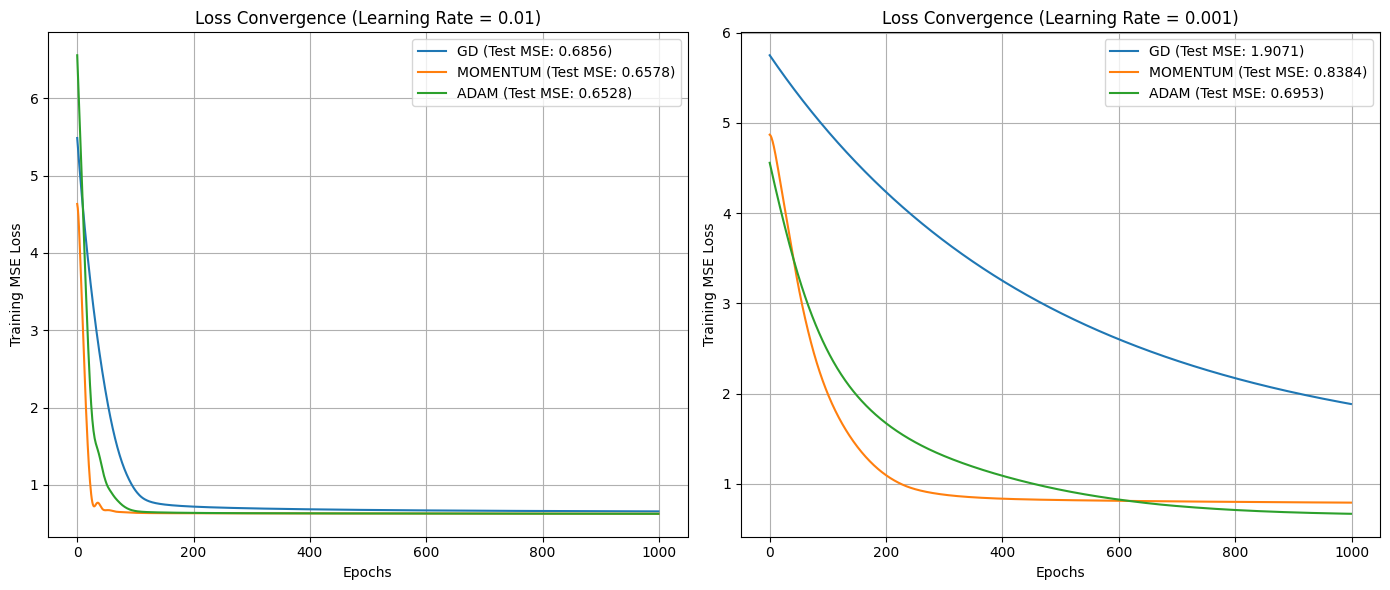

In [9]:
baseline_arch = [2, 5, 3, 1]  # Input: 2, Layer 1: 5, Layer 2: 3, Output: 1
epochs = 1000
optimizers = ['gd', 'momentum', 'adam']
learning_rates = [0.01, 0.001]

results = {}

plt.figure(figsize=(14, 6))

for lr in learning_rates:
    plt.subplot(1, 2, 1 if lr == 0.01 else 2)
    for opt in optimizers:
        model, loss_hist, test_preds, test_mse = train_model(
            baseline_arch, X_train, y_train, X_test, y_test,
            epochs=epochs, lr=lr, optimizer=opt
        )
        key = f"{opt}_lr_{lr}"
        results[key] = {
            'loss_history': loss_hist,
            'test_mse': test_mse,
            'preds': test_preds,
            'model': model
        }
        plt.plot(loss_hist, label=f"{opt.upper()} (Test MSE: {test_mse:.4f})")

    plt.title(f"Loss Convergence (Learning Rate = {lr})")
    plt.xlabel("Epochs")
    plt.ylabel("Training MSE Loss")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

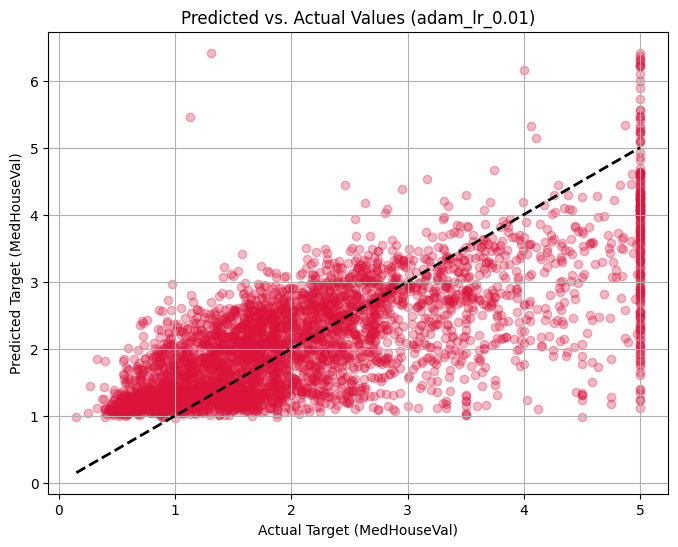

--- Optimizer Performance Summary ---
Configuration: gd_lr_0.01      | Test MSE: 0.68558
Configuration: momentum_lr_0.01 | Test MSE: 0.65785
Configuration: adam_lr_0.01    | Test MSE: 0.65285
Configuration: gd_lr_0.001     | Test MSE: 1.90709
Configuration: momentum_lr_0.001 | Test MSE: 0.83841
Configuration: adam_lr_0.001   | Test MSE: 0.69531


In [10]:
best_model_key = min(results, key=lambda k: results[k]['test_mse'])
best_preds = results[best_model_key]['preds']

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.3, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f"Predicted vs. Actual Values ({best_model_key})")
plt.xlabel("Actual Target (MedHouseVal)")
plt.ylabel("Predicted Target (MedHouseVal)")
plt.grid(True)
plt.show()

print(f"--- Optimizer Performance Summary ---")
for key, res in results.items():
    print(f"Configuration: {key:15s} | Test MSE: {res['test_mse']:.5f}")

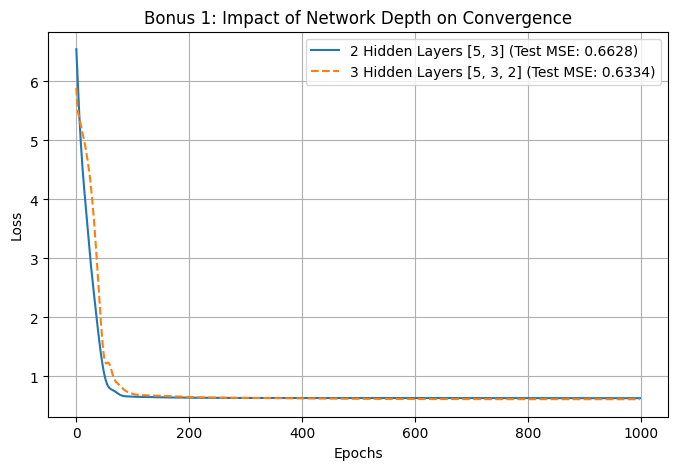

2 Hidden Layers Test MSE: 0.66279
3 Hidden Layers Test MSE: 0.63341


In [11]:
arch_2_hidden = [2, 5, 3, 1]
arch_3_hidden = [2, 5, 3, 2, 1]

# Train using Adam with lr=0.01
m2, loss2, preds2, mse2 = train_model(arch_2_hidden, X_train, y_train, X_test, y_test, epochs=1000, lr=0.01, optimizer='adam')
m3, loss3, preds3, mse3 = train_model(arch_3_hidden, X_train, y_train, X_test, y_test, epochs=1000, lr=0.01, optimizer='adam')

plt.figure(figsize=(8, 5))
plt.plot(loss2, label=f"2 Hidden Layers [5, 3] (Test MSE: {mse2:.4f})")
plt.plot(loss3, label=f"3 Hidden Layers [5, 3, 2] (Test MSE: {mse3:.4f})", linestyle='--')
plt.title("Bonus 1: Impact of Network Depth on Convergence")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print(f"2 Hidden Layers Test MSE: {mse2:.5f}")
print(f"3 Hidden Layers Test MSE: {mse3:.5f}")

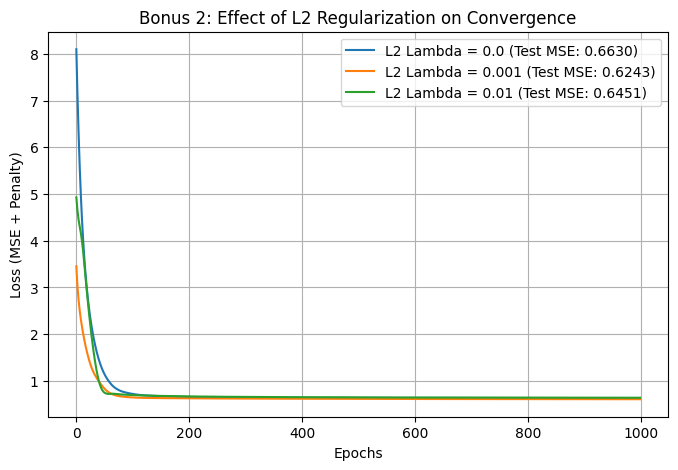

--- L2 Regularization Results ---
Lambda: 0.000000 | Test MSE: 0.66296
Lambda: 0.001000 | Test MSE: 0.62430
Lambda: 0.010000 | Test MSE: 0.64513


In [12]:
lambdas = [0.0, 0.001, 0.01]
reg_results = {}

plt.figure(figsize=(8, 5))
for l2 in lambdas:
    m_reg, loss_reg, preds_reg, mse_reg = train_model(
        arch_2_hidden, X_train, y_train, X_test, y_test,
        epochs=1000, lr=0.01, optimizer='adam', l2_lambda=l2
    )
    plt.plot(loss_reg, label=f"L2 Lambda = {l2} (Test MSE: {mse_reg:.4f})")
    reg_results[l2] = mse_reg

plt.title("Bonus 2: Effect of L2 Regularization on Convergence")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE + Penalty)")
plt.legend()
plt.grid(True)
plt.show()

print("--- L2 Regularization Results ---")
for l2, mse in reg_results.items():
    print(f"Lambda: {l2:5f} | Test MSE: {mse:.5f}")